In [23]:
import os
import numpy as np
import xarray as xr
import pickle
import glob
import warnings
from pathlib import Path, PureWindowsPath
import re
import matplotlib.pyplot as plt

import cedalion
import cedalion.sigproc.motion as motion_correct
import cedalion.sigproc.quality as quality
import cedalion.sigproc.physio as physio
import cedalion.dot as dot
import cedalion.nirs as nirs
from cedalion.io.forward_model import load_Adot
import cedalion.dataclasses as cdc    
from cedalion import units
import copy
from matplotlib import pyplot as plt

warnings.filterwarnings("ignore")

In [24]:
base_path = "/home/orabe/fNIRS_sparseToDense/"

# Available datasets:
# DATASET_NAME = "BallSqueezingHD_modified"
# DATASET_NAME = "FreshMotor"
# DATASET_NAME = "BS_Laura"
DATASET_NAME = "vfc_hd"
# DATASET_NAME = "Anderson_sparse"

raw_path = Path(f'datasets/raw/{DATASET_NAME}')

In [25]:
if DATASET_NAME == "BallSqueezingHD_modified":
    raw_dir = f"{raw_path}/sub-*/nirs/sub-*.snirf"

elif DATASET_NAME == "BS_Laura":
    raw_dir = f"{raw_path}/sub-*/nirs/sub-*.snirf"
    
elif DATASET_NAME == "Anderson_sparse":
    raw_dir = f"{raw_path}/sub-*/nirs/sub-*_ses-*_task-WordStroop_run-*_nirs.snirf"    
    
elif DATASET_NAME == "vfc_hd":
    raw_dir = f"{raw_path}/sub-*/nirs/sub-*_ses-*_task-WordStroop_run-*_nirs.snirf"    
    
elif DATASET_NAME == "Electrical_Thermal":
    raw_dir = f"{raw_path}/sub-*/ses-*/nirs/sub-*_ses-*_task-Electrical*_nirs.snirf"
    # TODO: exclude subjects without txt files for landmarks coords
    
elif DATASET_NAME == "FreshMotor":
    duration = "*" # * to include both 2s and 3s
    raw_dir = f"{raw_path}/sub-*/ses-*{duration}/nirs/sub-*_ses-*{duration}_task-FRESHMOTOR_nirs.snirf"

else:
    raise ValueError("Unknown dataset name")

files = glob.glob(raw_dir)

# TODO: to be confirmed
# remove non-BS files for Laura's dataset to avoid errors
if DATASET_NAME == "BS_Laura":
    files = [p for p in files if "BS" in os.path.basename(p)]
    
    # remove files that has this pattern in the name: _acq-4NN_nirs:
    files = [p for p in files if "_acq-4NN_nirs" not in os.path.basename(p)]
    
files = sorted(files)
print(f"{len(files)} files found.")

17 files found.


In [26]:
filename = files[0] # select one
rec = cedalion.io.read_snirf(filename)[0]  # read snirf files
original_channel_size = rec['amp'].channel.size
rec['amp']

Magnitude,[[[0.06030874 0.06037754 0.060458160000000004 ... 0.05730901 0.05736409 0.05745425] [0.29471219 0.29535324 0.29571803 ... 0.28067827 0.28065279 0.28068766]] [[0.1731772 0.17336796 0.17342894 ... 0.18193879 0.18193863 0.18179209] [0.4302586 0.43097464 0.43138836 ... 0.43282082 0.4328796 0.43287878]] [[0.1428678 0.14289844 0.1430421 ... 0.14058984 0.14065344 0.14054604] [0.6849146 0.68576684 0.68627289 ... 0.66783071 0.66815009 0.66836309]] ... [[0.21728043 0.21756437 0.21748848 ... 0.23626250999999998 0.23648460999999998 0.23669541] [0.49451371 0.49527606999999996 0.49558205 ... 0.5315197399999999 0.53207396 0.53286545]] [[0.07503049 0.07514841 0.07524451 ... 0.08111948 0.08100512 0.08112406999999999] [0.21976587 0.21999906 0.22016017000000002 ... 0.23333407 0.2332858 0.23345148999999998]] [[0.01210751 0.0121231 0.01215625 ... 0.01184892 0.011867860000000001 0.01186877] [0.02068223 0.02070139 0.02067002 ... 0.02021633 0.02025814 0.0202276]]]
Units,dimensionless


# This step is just to simply plot the original data

In [27]:
# filter channels based on the valid channels after pruning with sd_dist
meas_list = rec._measurement_lists["amp"]

# We remove this step here for visualization purposes
# meas_list = meas_list[meas_list["channel"].isin(ds_ch[chd_mask].channel.values)].reset_index(drop=True)

# both should then be equal
print(f'Number of channels in rec["amp"]: {len(set(rec["amp"].channel.values))}')
print(f'Number of channels in meas_list: {len(set(meas_list.channel.values))}')


head_icbm152 = dot.get_standard_headmodel('icbm152')  

if DATASET_NAME == "BS_Laura":
    # this is required for BU Data (Laura's)
    T = np.array([
        [-9.57882733e-01, -7.20806358e-03,  6.20193531e-03, 2.21208571e+02],
        [-2.02271710e-02,  6.03819925e-02,  9.94046165e-01, -2.03010603e+01],
        [-8.79481533e-03, -1.02761992e+00,  6.59199998e-02, 2.87749135e+02],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, 1.00000000e+00]])
    
    print("Applying transformation for Laura's data")
    ninja_aligned = rec.geo3d.points.apply_transform(T)
    geo3d_snapped_ijk = head_icbm152.align_and_snap_to_scalp(ninja_aligned)
else:
    geo3d_snapped_ijk = head_icbm152.align_and_snap_to_scalp(rec.geo3d)


geo3d_snapped_ijk = geo3d_snapped_ijk[geo3d_snapped_ijk.type != cdc.PointType.LANDMARK]


Number of channels in rec["amp"]: 214
Number of channels in meas_list: 214


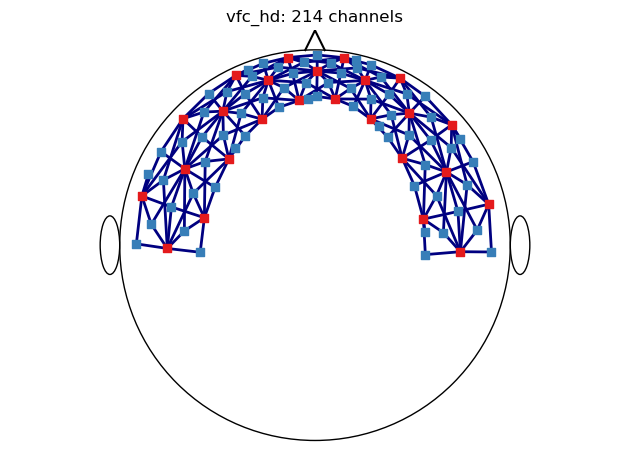

In [28]:
from cedalion.vis.anatomy import plot_montage3D

# plot_montage3D(rec["amp"], rec.geo3d)

fig, ax = plt.subplots(1, 1)
cedalion.vis.anatomy.scalp_plot(
    rec['amp'],
    ninja_aligned if DATASET_NAME == "BS_Laura" else rec.geo3d,
    # geo3d_snapped_ijk
    np.ones(rec['amp'].channel.size),
    ax,
    cmap="jet",
    title=f"{DATASET_NAME}: {rec['amp'].channel.size} channels",
    vmin=1,
    vmax=1,
    cb_label="",
    add_colorbar=False,
)
plt.tight_layout()

# Start the analysis: reload sample data

In [29]:
filename = files[0] # select one
rec = cedalion.io.read_snirf(filename)[0]  # read snirf files
original_channel_size = rec['amp'].channel.size
rec['amp']

Magnitude,[[[0.06030874 0.06037754 0.060458160000000004 ... 0.05730901 0.05736409 0.05745425] [0.29471219 0.29535324 0.29571803 ... 0.28067827 0.28065279 0.28068766]] [[0.1731772 0.17336796 0.17342894 ... 0.18193879 0.18193863 0.18179209] [0.4302586 0.43097464 0.43138836 ... 0.43282082 0.4328796 0.43287878]] [[0.1428678 0.14289844 0.1430421 ... 0.14058984 0.14065344 0.14054604] [0.6849146 0.68576684 0.68627289 ... 0.66783071 0.66815009 0.66836309]] ... [[0.21728043 0.21756437 0.21748848 ... 0.23626250999999998 0.23648460999999998 0.23669541] [0.49451371 0.49527606999999996 0.49558205 ... 0.5315197399999999 0.53207396 0.53286545]] [[0.07503049 0.07514841 0.07524451 ... 0.08111948 0.08100512 0.08112406999999999] [0.21976587 0.21999906 0.22016017000000002 ... 0.23333407 0.2332858 0.23345148999999998]] [[0.01210751 0.0121231 0.01215625 ... 0.01184892 0.011867860000000001 0.01186877] [0.02068223 0.02070139 0.02067002 ... 0.02021633 0.02025814 0.0202276]]]
Units,dimensionless


# Distance filtering

In [30]:
# new since 13-07-2026
min_d, max_d = 1, 4.5
ds_ch, chd_mask = quality.sd_dist(rec["amp"], rec.geo3d, [min_d, max_d]*units.cm)
rec['amp'], _ = quality.prune_ch(rec["amp"], [chd_mask], "all")


In [31]:
# filter channels based on the valid channels after pruning with sd_dist
meas_list = rec._measurement_lists["amp"]
meas_list = meas_list[meas_list["channel"].isin(ds_ch[chd_mask].channel.values)].reset_index(drop=True)

# both should then be equal
print(f'Number of channels in rec["amp"]: {len(set(rec["amp"].channel.values))}')
print(f'Number of channels in meas_list: {len(set(meas_list.channel.values))}')


head_icbm152 = dot.get_standard_headmodel('icbm152')  

if DATASET_NAME == "BS_Laura":
    # this is required for BU Data (Laura's)
    T = np.array([
        [-9.57882733e-01, -7.20806358e-03,  6.20193531e-03, 2.21208571e+02],
        [-2.02271710e-02,  6.03819925e-02,  9.94046165e-01, -2.03010603e+01],
        [-8.79481533e-03, -1.02761992e+00,  6.59199998e-02, 2.87749135e+02],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, 1.00000000e+00]])
    
    print("Applying transformation for Laura's data")
    ninja_aligned = rec.geo3d.points.apply_transform(T)
    geo3d_snapped_ijk = head_icbm152.align_and_snap_to_scalp(ninja_aligned)
else:
    geo3d_snapped_ijk = head_icbm152.align_and_snap_to_scalp(rec.geo3d)

import cedalion.dataclasses as cdc    
geo3d_snapped_ijk = geo3d_snapped_ijk[geo3d_snapped_ijk.type != cdc.PointType.LANDMARK]


fwm = cedalion.dot.forward_model.ForwardModel(
    head_icbm152, 
    geo3d_snapped_ijk,
    meas_list
)

pre_processed_path = Path(f'datasets/pre_processed/base/{DATASET_NAME}/full')
# pre_processed_path.mkdir(parents=True, exist_ok=True)
fluence_fname = os.path.join(pre_processed_path, "fluence_" + DATASET_NAME + ".h5")
sensitivity_fname = os.path.join(pre_processed_path, "sensitivity_" + DATASET_NAME + ".h5")

print(f"Fluence file: {fluence_fname}")
print(f"Sensitivity file: {sensitivity_fname}")

# compute fluence and sensitivity only once
# fwm.compute_fluence_mcx(fluence_fname)
# fwm.compute_sensitivity(fluence_fname, sensitivity_fname)

Adot = load_Adot(sensitivity_fname)
print(f"Adot shape: {Adot.shape}")

Number of channels in rec["amp"]: 206
Number of channels in meas_list: 206
Fluence file: datasets/pre_processed/base/vfc_hd/full/fluence_vfc_hd.h5
Sensitivity file: datasets/pre_processed/base/vfc_hd/full/sensitivity_vfc_hd.h5
Adot shape: (206, 35018, 2)


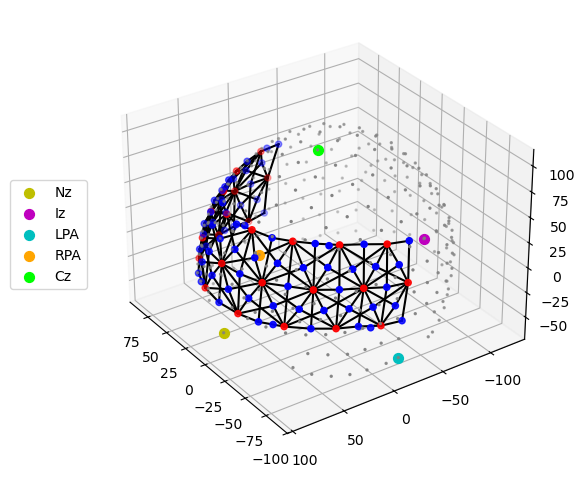

In [32]:
from cedalion.vis.anatomy import plot_montage3D

plot_montage3D(rec["amp"], rec.geo3d)

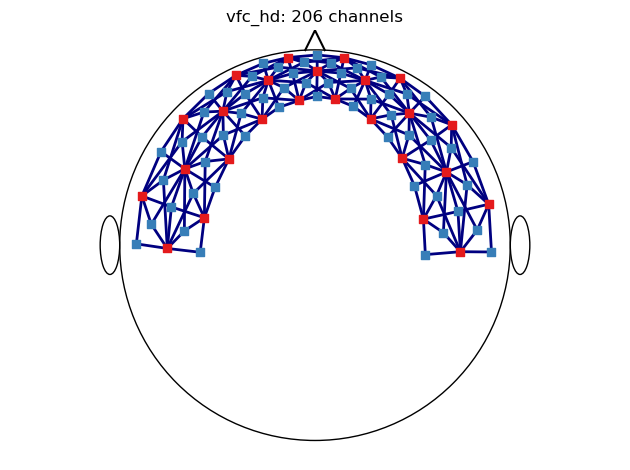

In [33]:
fig, ax = plt.subplots(1, 1)
cedalion.vis.anatomy.scalp_plot(
    rec['amp'],
    # geo3d_snapped_ijk,
    # ninja_aligned,
    rec.geo3d,
    np.ones(rec['amp'].channel.size),
    ax,
    cmap="jet",
    title=f"{DATASET_NAME}: {rec['amp'].channel.size} channels",
    vmin=1,
    vmax=1,
    cb_label="",
    add_colorbar=False,
)
plt.tight_layout()

In [12]:
rec['amp'].shape

(206, 2, 6712)

In [13]:
# build sensitivity once
parcel_dOD, parcel_mask = fwm.parcel_sensitivity(
    Adot,
    [],  # bad channels list
    dOD_thresh=0.001,
    minCh=1,
    dHbO=10,
    dHbR=-3
)

In [14]:
parcel_dOD.shape, parcel_mask.shape

((2, 206, 601), (601,))

In [15]:
print((parcel_mask.data == True).sum())
print((parcel_mask.data == False).sum())

# parcel_dOD.parcel[parcel_mask]

145
456


In [16]:
if DATASET_NAME == "BallSqueezingHD_modified":
    sens_parcel_yuanyuan_path = 'datasets/pre_processed/base/BallSqueezingHD_modified/full/parcel_template_BallSqueezingHD_modified.pkl'

    with open(sens_parcel_yuanyuan_path, 'rb') as handle:
        template_sens_parcel_list = pickle.load(handle)

    print(f"Number of parcels in Yuanyuan's template: {len(template_sens_parcel_list)}")

    # Keep only motor parcels in the template list
    template_sens_parcel_list = [l for l in template_sens_parcel_list if l.startswith("SomMot")]
    print(f"Number of motor parcels in Yuanyuan's template: {len(template_sens_parcel_list)}")
    
    # use the parcel_mask to select filter the parcels
    parcel_dOD_masked = parcel_dOD.sel(parcel=parcel_dOD.parcel[parcel_mask])
    
    # keep only parcels that are in the template list from Yuanyuan dataset (bsq-hd)
    parcel_dOD_valid = parcel_dOD_masked.sel(parcel=[i for i in template_sens_parcel_list if i in parcel_dOD_masked.parcel.data])
    parcel_dOD_valid.shape # 47 for yuanyuan

In [17]:
if DATASET_NAME == "BS_Laura":
    # Here we decide to use parcels with SomMot in the name instead of using the template list from Yuanyuan's data.
    # Keep only motor parcels in the template list
    # currently use option 2 

    # option 1: keep everything that starts with "SomMot" in the parcel_dOD.parcel.data
    # template_sens_parcel_list_SomMot = [l for l in parcel_dOD.parcel.data if l.startswith("SomMot")]
    # print(f"Number of motor parcels in the parcel_dOD.parcel.data: {len(template_sens_parcel_list_SomMot)}")

    # option 2: keep everything that starts with "SomMot" in the parcel_dOD.parcel.data, but only for the parcels that are in the parcel_mask
    template_sens_parcel_list_SomMot = [l for l in parcel_dOD.parcel.data[parcel_mask] if l.startswith("SomMot")]
    print(len(template_sens_parcel_list_SomMot))
    
    # use the parcel_mask to select filter the parcels
    parcel_dOD_masked = parcel_dOD.sel(parcel=parcel_dOD.parcel[parcel_mask])
    
    parcel_dOD_valid = parcel_dOD_masked.sel(parcel=[i for i in template_sens_parcel_list_SomMot if i in parcel_dOD_masked.parcel.data])
    
    print(f"Number of motor parcels in the parcel_dOD_valid: {len(parcel_dOD_valid.parcel.data)}")

In [18]:
if DATASET_NAME == "vfc_hd":
    sens_parcel_yuanyuan_path = 'datasets/pre_processed/base/Anderson_sparse/full/parcel_template_Anderson_sparse.pkl'

    with open(sens_parcel_yuanyuan_path, 'rb') as handle:
        template_sens_parcel_list = pickle.load(handle)

    print(f"Number of parcels in Anderson_sparse's template: {len(template_sens_parcel_list)}")

    # Keep only motor parcels in the template list    
    # use the parcel_mask to select filter the parcels
    parcel_dOD_masked = parcel_dOD.sel(parcel=parcel_dOD.parcel[parcel_mask])
    
    # keep only parcels that are in the template list from Anderson_sparse dataset
    parcel_dOD_valid = parcel_dOD_masked.sel(parcel=[i for i in template_sens_parcel_list if i in parcel_dOD_masked.parcel.data])
    parcel_dOD_valid.shape

Number of parcels in Anderson_sparse's template: 136


In [19]:
parcel_dOD_valid

<xarray.DataArray (wavelength: 2, channel: 206, parcel: 132)> Size: 435kB
array([[[4.16564706e-04, 1.89301585e-20, 3.71564737e-11, ...,
         2.63007456e-10, 2.55749600e-25, 2.33638645e-09],
        [1.52655592e-05, 2.10501931e-19, 2.39559572e-09, ...,
         7.07660978e-11, 1.32824531e-23, 1.87415672e-10],
        [5.78171155e-05, 4.84643934e-21, 9.84646881e-11, ...,
         2.78356927e-09, 7.40714021e-25, 1.59285852e-08],
        ...,
        [9.44862457e-27, 2.98208474e-07, 1.25901341e-21, ...,
         5.84290153e-23, 5.94110893e-06, 7.63627263e-24],
        [1.52020756e-26, 2.64465750e-06, 5.99267816e-21, ...,
         2.36441720e-21, 6.07090941e-09, 5.11095882e-23],
        [1.54555365e-27, 3.20910328e-08, 8.10569389e-23, ...,
         6.81790138e-23, 1.08163976e-06, 3.88534791e-24]],

       [[2.91765427e-03, 1.32588424e-19, 2.60247070e-10, ...,
         1.84212636e-09, 1.79129173e-24, 1.63642474e-08],
        [1.06921262e-04, 1.47437325e-18, 1.67789541e-08, ...,
         4.95651706e-10, 9.30314196e-23, 1.31267514e-09],
        [4.04955944e-04, 3.39448691e-20, 6.89654965e-10, ...,
         1.94963535e-08, 5.18802336e-24, 1.11565152e-07],
        ...,
        [6.61789619e-26, 2.08867726e-06, 8.81823589e-21, ...,
         4.09241742e-22, 4.16120271e-05, 5.34850964e-23],
        [1.06476617e-25, 1.85234038e-05, 4.19732223e-20, ...,
         1.65605771e-20, 4.25211606e-08, 3.57975859e-22],
        [1.08251879e-26, 2.24768295e-07, 5.67729624e-22, ...,
         4.77531553e-22, 7.57589595e-06, 2.72133038e-23]]],
      shape=(2, 206, 132))
Coordinates:
  * channel     (channel) object 2kB 'S1D1' 'S1D2' 'S1D10' ... 'S25D57' 'S25D58'
  * parcel      (parcel) object 1kB 'ContA_IPS_3_RH' ... 'TempPar_6_RH'
  * wavelength  (wavelength) float64 16B 760.0 850.0

# For each parcel, select the k channels that have the highest sensitivity values.

Selected 97 unique channels
Coverage: 264 total assignments (channel-parcel pairs)
206 -->       97 channels after top-k selection


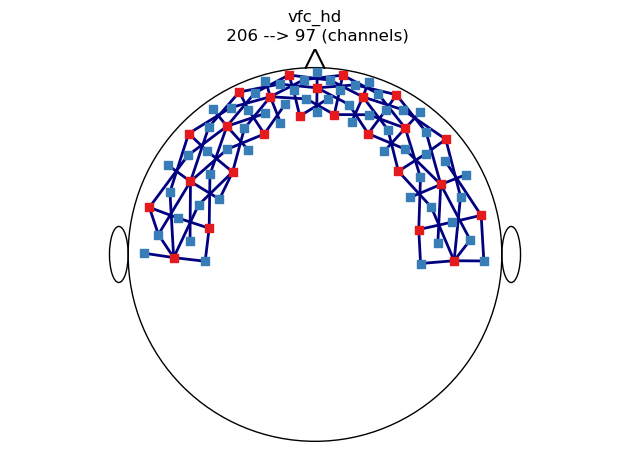

In [20]:
# The general idea of this approach is to loop over parcels and keep the top k channels per parcel based on sensitivity.

k = 2  # top channels per parcel
channels_per_parcel = []

# for parcel in parcel_dOD_valid.parcel.values:
# for parcel in parcel_dOD_valid.sel(channel=chd_mask).parcel.values:
for parcel in parcel_dOD_valid.parcel.values:
    
    # Get sensitivity for this specific parcel
    # parcel_sens = np.abs(parcel_dOD_valid.sel(parcel=parcel)).mean(dim="wavelength")
    parcel_sens = np.abs(parcel_dOD_valid.sel(parcel=parcel, wavelength=850.0))
    
    # Get top k channels for this parcel (sort descending, take first k)
    top_k_channels = parcel_sens.sortby(parcel_sens, ascending=False).channel.values[:k]
    channels_per_parcel.extend(top_k_channels)

# Get unique channels (same channel can be top-k for multiple parcels)
unique_channels = np.unique(channels_per_parcel)

print(f"Selected {len(unique_channels)} unique channels")
print(f"Coverage: {len(channels_per_parcel)} total assignments (channel-parcel pairs)")

rec['amp_topK'] = rec['amp'].sel(channel=[c for c in unique_channels if c in rec['amp'].channel.values])

print(f"{rec['amp'].channel.values.size} --> \
      {rec['amp_topK'].channel.values.size} channels after top-k selection")

# plot_montage3D(rec['amp_k'], rec.geo3d)
fig, ax = plt.subplots(1, 1)
cedalion.vis.anatomy.scalp_plot(
    rec['amp_topK'],
    rec.geo3d,
    np.ones(rec['amp_topK'].channel.size),
    ax,
    cmap="jet",
    title=f"{DATASET_NAME}\n {rec['amp'].channel.values.size} --> {rec['amp_topK'].channel.size} (channels)",
    vmin=1,
    vmax=1,
    cb_label="",
    add_colorbar=False,
)
plt.tight_layout()


# Filter channels based on closest optodes to C3 and C4

In [21]:
if DATASET_NAME in ["BallSqueezingHD_modified", "BS_Laura"]:
    # Get the closest optodes to C3 and C4 landmarks and filter the channels accordingly.
    c3_c4_d = 20

    # Function to get indices of closest optodes
    def get_closest_optodes(optodes, landmark_coord, d=10):
        distances = np.linalg.norm(optodes - landmark_coord, axis=1)
        closest_indices = np.argsort(distances)[:d]
        return list(optodes.label[closest_indices].values)

    closest_c3_indices = get_closest_optodes(
        geo3d_snapped_ijk,
        head_icbm152.landmarks.sel(label='C3'),
        d=c3_c4_d
    )

    closest_c4_indices = get_closest_optodes(
        geo3d_snapped_ijk,
        head_icbm152.landmarks.sel(label='C4'),
        d=c3_c4_d
    )

    # closest_cz_indices = get_closest_optodes(
    #     geo3d_snapped_ijk,
    #     head_icbm152.landmarks.sel(label='Cz'),
    #     k=30
    # )

    closest_indices = list(set(closest_c3_indices + closest_c4_indices))


    mask_c3_c4 = rec['amp_topK'].source.isin(closest_indices) & rec['amp_topK'].detector.isin(closest_indices)
    rec['amp_topK_c3c4d'] = rec['amp_topK'].sel(channel=mask_c3_c4)

    print(f"{rec['amp'].channel.values.size} --> {rec['amp_topK'].channel.values.size} --> {rec['amp_topK_c3c4d'].channel.values.size} channels")  


    n_channels = rec["amp_topK_c3c4d"].channel.size
    os.makedirs(f'datasets/pre_processed/base/{DATASET_NAME}/{n_channels}_chs/', exist_ok=True)

    filename = (
        f"datasets/pre_processed/base/{DATASET_NAME}/{n_channels}_chs/"
        f"channel_names__"
        f"maxDist={max_d}__"
        f"topK={k}__"
        f"c3c4d={c3_c4_d}__"
        f"{n_channels}chs"
    )


    fig, ax = plt.subplots(1, 1)
    fig.set_size_inches(5, 5)

    # plot_montage3D(rec["amp_c3c4_d"], rec.geo3d)
    import cedalion.vis.anatomy.scalp_plot
    cedalion.vis.anatomy.scalp_plot(
        rec['amp_topK_c3c4d'],
        # geo3d_snapped_ijk,
        rec.geo3d,
        np.ones(rec['amp_topK_c3c4d'].channel.size),
        ax,
        cmap="jet",
        title=f"{DATASET_NAME}\n {rec['amp'].channel.values.size} ---> {rec['amp_topK'].channel.size} (k={k}) ---> {rec['amp_topK_c3c4d'].channel.size} (c3c4d={c3_c4_d}) channels",
        vmin=1,
        vmax=1,
        # cb_label="",
        add_colorbar=False,
    )
    plt.tight_layout()

    plt.savefig(f'{filename}.png')

    np.save(filename + ".npy", rec["amp_topK_c3c4d"].channel.values)

206 --> 97 --> 90 channels


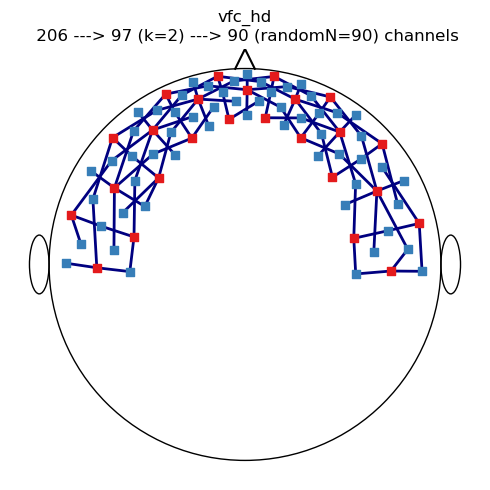

In [28]:
if DATASET_NAME in ["vfc_hd"]:
        
    N = 90
    RANDOM_SEED = 42

    import re
    import numpy as np
    import xarray as xr


    def _to_numpy_positions(points, unit="mm"):
        """
        Convert a Cedalion LabeledPoints selection to a plain NumPy array.

        Handles both pint-quantified and ordinary xarray DataArrays.
        """
        try:
            points = points.pint.to(unit).pint.dequantify()
        except (AttributeError, ValueError):
            pass

        return np.asarray(points.values, dtype=float)

    def _extract_source_detector_labels(ts):
        """
        Get source and detector labels for every channel.

        Cedalion NDTimeSeries objects normally contain `source` and `detector`
        as channel-level coordinates. Channel-name parsing is used only as a
        fallback.
        """
        channel_names = ts.channel.values.astype(str)

        if "source" in ts.coords and "detector" in ts.coords:
            source_labels = ts.coords["source"].values.astype(str)
            detector_labels = ts.coords["detector"].values.astype(str)
            return source_labels, detector_labels

        # Fallback for channel names such as S10D13
        pattern = re.compile(r"^(S\d+)(D\d+)$")

        source_labels = []
        detector_labels = []

        for channel_name in channel_names:
            match = pattern.match(channel_name)

            if match is None:
                raise ValueError(
                    f"Cannot parse source and detector from channel "
                    f"name {channel_name!r}."
                )

            source_labels.append(match.group(1))
            detector_labels.append(match.group(2))

        return np.asarray(source_labels), np.asarray(detector_labels)

    def get_channel_midpoints(ts, geo3d, unit="mm", project_to_scalp=True):
        """
        Compute one 3D location per source-detector channel.

        Parameters
        ----------
        ts
            Cedalion/xarray channel-space time series.
        geo3d
            Cedalion LabeledPoints containing optode coordinates.
        unit
            Unit used after dequantification.
        project_to_scalp
            Project midpoint directions onto a common sphere around the
            optode-cloud center. This prevents Euclidean source-detector
            midpoints from lying slightly inside the head.

        Returns
        -------
        positions : ndarray, shape (n_channels, 3)
            Channel-center coordinates.
        """
        source_labels, detector_labels = _extract_source_detector_labels(ts)

        source_positions = _to_numpy_positions(
            geo3d.sel(label=xr.DataArray(source_labels, dims="channel")),
            unit=unit,
        )
        detector_positions = _to_numpy_positions(
            geo3d.sel(label=xr.DataArray(detector_labels, dims="channel")),
            unit=unit,
        )

        channel_positions = 0.5 * (source_positions + detector_positions)

        if project_to_scalp:
            optode_labels = np.unique(
                np.concatenate([source_labels, detector_labels])
            )

            optode_positions = _to_numpy_positions(
                geo3d.sel(label=optode_labels),
                unit=unit,
            )

            head_center = optode_positions.mean(axis=0)

            optode_radii = np.linalg.norm(
                optode_positions - head_center,
                axis=1,
            )
            scalp_radius = np.median(optode_radii)

            directions = channel_positions - head_center
            norms = np.linalg.norm(directions, axis=1, keepdims=True)

            if np.any(norms == 0):
                raise ValueError(
                    "At least one channel midpoint coincides with the "
                    "estimated head center."
                )

            channel_positions = (
                head_center
                + scalp_radius * directions / norms
            )

        return channel_positions

    def spatially_balanced_channel_sample(
        ts,
        geo3d,
        n_channels,
        seed=None,
        randomness=0.20,
        distance_power=2.0,
    ):
        """
        Select a spatially distributed subset of channels.

        The algorithm is randomized farthest-point sampling. At each step, it
        considers the most spatially isolated remaining candidates and randomly
        selects one of them.

        Parameters
        ----------
        ts
            Candidate channel-space DataArray, e.g. rec["amp_topK"].
        geo3d
            Cedalion geometry.
        n_channels
            Number of channels to select.
        seed
            Random seed for reproducibility.
        randomness
            Fraction of remaining channels considered at every iteration.

            0.0:
                Nearly deterministic farthest-point sampling.
            0.1 to 0.3:
                Spatially balanced but randomized sampling.
            1.0:
                Much more random and less spatially regular.
        distance_power
            Controls preference for spatially isolated candidates.

        Returns
        -------
        selected_channels : ndarray
            Selected channel names.
        selected_indices : ndarray
            Corresponding indices in `ts.channel`.
        positions : ndarray
            Positions of all candidate channels.
        """
        channel_names = ts.channel.values
        total_channels = len(channel_names)

        if not 1 <= n_channels <= total_channels:
            raise ValueError(
                f"`n_channels` must be between 1 and {total_channels}; "
                f"received {n_channels}."
            )

        if not 0.0 <= randomness <= 1.0:
            raise ValueError("`randomness` must be between 0 and 1.")

        rng = np.random.default_rng(seed)

        positions = get_channel_midpoints(
            ts=ts,
            geo3d=geo3d,
            project_to_scalp=True,
        )

        # Standardise scale only; preserve spatial geometry.
        position_scale = np.std(positions, axis=0)
        position_scale[position_scale == 0] = 1.0
        scaled_positions = positions / position_scale

        # Random starting channel.
        first_index = int(rng.integers(total_channels))
        selected_indices = [first_index]

        # Distance from every candidate to its closest selected channel.
        nearest_distance = np.linalg.norm(
            scaled_positions - scaled_positions[first_index],
            axis=1,
        )
        nearest_distance[first_index] = -np.inf

        while len(selected_indices) < n_channels:
            available_indices = np.flatnonzero(
                np.isfinite(nearest_distance)
            )

            # Consider only the spatially best-separated candidate pool.
            if randomness == 0:
                candidate_pool_size = 1
            else:
                candidate_pool_size = max(
                    2,
                    int(np.ceil(randomness * len(available_indices))),
                )

            candidate_pool_size = min(
                candidate_pool_size,
                len(available_indices),
            )

            sorted_available = available_indices[
                np.argsort(nearest_distance[available_indices])[::-1]
            ]

            candidate_pool = sorted_available[:candidate_pool_size]

            # Candidates farther from the existing subset receive higher weight.
            weights = np.maximum(
                nearest_distance[candidate_pool],
                np.finfo(float).eps,
            ) ** distance_power
            weights /= weights.sum()

            next_index = int(
                rng.choice(candidate_pool, p=weights)
            )
            selected_indices.append(next_index)

            distance_to_new_channel = np.linalg.norm(
                scaled_positions - scaled_positions[next_index],
                axis=1,
            )

            nearest_distance = np.minimum(
                nearest_distance,
                distance_to_new_channel,
            )

            nearest_distance[selected_indices] = -np.inf

        selected_indices = np.asarray(selected_indices, dtype=int)

        return (
            channel_names[selected_indices],
            selected_indices,
            positions,
        )
        
    selected_channels, selected_indices, channel_positions = (
        spatially_balanced_channel_sample(
            ts=rec["amp_topK"],
            geo3d=rec.geo3d,
            n_channels=N,
            seed=RANDOM_SEED,
            randomness=0.20,
            distance_power=2.0,
        )
    )

    rec["amp_topK_randomN"] = rec["amp_topK"].isel(
        channel=selected_indices
    )
    
    
    # continue as before
    print(f"{rec['amp'].channel.values.size} --> {rec['amp_topK'].channel.values.size} --> {rec['amp_topK_randomN'].channel.values.size} channels")  
    
    n_channels = rec["amp_topK_randomN"].channel.size
    os.makedirs(f'datasets/pre_processed/base/{DATASET_NAME}/{n_channels}_chs/', exist_ok=True)

    filename = (
        f"datasets/pre_processed/base/{DATASET_NAME}/{n_channels}_chs/"
        f"channel_names__"
        f"maxDist={max_d}__"
        f"topK={k}__"
        f"randomN={N}__"
        f"{n_channels}chs"
    )


    fig, ax = plt.subplots(1, 1)
    fig.set_size_inches(5, 5)

    # plot_montage3D(rec["amp_c3c4_d"], rec.geo3d)
    import cedalion.vis.anatomy.scalp_plot
    cedalion.vis.anatomy.scalp_plot(
        rec['amp_topK_randomN'],
        # geo3d_snapped_ijk,
        rec.geo3d,
        np.ones(rec['amp_topK_randomN'].channel.size),
        ax,
        cmap="jet",
        title=f"{DATASET_NAME}\n {rec['amp'].channel.values.size} ---> {rec['amp_topK'].channel.size} (k={k}) ---> {rec['amp_topK_randomN'].channel.size} (randomN={N}) channels",
        vmin=1,
        vmax=1,
        # cb_label="",
        add_colorbar=False,
    )
    plt.tight_layout()

    plt.savefig(f'{filename}.png')

    np.save(filename + ".npy", rec["amp_topK_randomN"].channel.values)    
    

In [29]:
channel_subset = np.load(filename + ".npy", allow_pickle=True)
channel_subset.size

90

In [30]:
from pathlib import Path
import numpy as np

subset_files = sorted(Path('datasets/pre_processed/base/BallSqueezingHD_modified').glob('*/channel_names_*.npy'))
assert subset_files, 'No channel subset npy files found.'

for i, f in enumerate(subset_files):
    print(f'[{i}] {f.name}')

reference_idx = 0  # change this index to use a different reference set
reference_file = subset_files[reference_idx]

channel_sets = {
    f.name: set(np.load(f, allow_pickle=True).tolist())
    for f in subset_files
}

ref_set = channel_sets[reference_file.name]
overlap_summary = []
for f in subset_files:
    name = f.name
    s = channel_sets[name]
    overlap = ref_set & s
    overlap_summary.append({
        'file': name,
        'n_channels': len(s),
        'n_overlap_with_ref': len(overlap),
        'pct_ref_covered': 100.0 * len(overlap) / len(ref_set) if ref_set else 0.0,
        'pct_set_overlaps_ref': 100.0 * len(overlap) / len(s) if s else 0.0,
    })

overlap_summary = sorted(overlap_summary, key=lambda x: x['n_overlap_with_ref'], reverse=True)
print(f'\nReference: {reference_file.name} ({len(ref_set)} channels)')
overlap_summary


[0] channel_names__maxDist=4.5__topK=3__c3c4d=23__43chs.npy
[1] channel_names__maxDist=4.5__topK=5__c3c4d=23__55chs.npy
[2] channel_names__maxDist=4.5__topK=6__c3c4d=23__68chs.npy
[3] channel_names__maxDist=4.5__topK=8__c3c4d=23__79chs.npy
[4] channel_names__maxDist=4.5__topK=13__c3c4d=23__91chs.npy

Reference: channel_names__maxDist=4.5__topK=3__c3c4d=23__43chs.npy (43 channels)


[{'file': 'channel_names__maxDist=4.5__topK=3__c3c4d=23__43chs.npy',
  'n_channels': 43,
  'n_overlap_with_ref': 43,
  'pct_ref_covered': 100.0,
  'pct_set_overlaps_ref': 100.0},
 {'file': 'channel_names__maxDist=4.5__topK=5__c3c4d=23__55chs.npy',
  'n_channels': 55,
  'n_overlap_with_ref': 43,
  'pct_ref_covered': 100.0,
  'pct_set_overlaps_ref': 78.18181818181819},
 {'file': 'channel_names__maxDist=4.5__topK=6__c3c4d=23__68chs.npy',
  'n_channels': 68,
  'n_overlap_with_ref': 43,
  'pct_ref_covered': 100.0,
  'pct_set_overlaps_ref': 63.23529411764706},
 {'file': 'channel_names__maxDist=4.5__topK=8__c3c4d=23__79chs.npy',
  'n_channels': 79,
  'n_overlap_with_ref': 43,
  'pct_ref_covered': 100.0,
  'pct_set_overlaps_ref': 54.43037974683544},
 {'file': 'channel_names__maxDist=4.5__topK=13__c3c4d=23__91chs.npy',
  'n_channels': 91,
  'n_overlap_with_ref': 43,
  'pct_ref_covered': 100.0,
  'pct_set_overlaps_ref': 47.252747252747255}]